# GEE LAI, NDVI, and ET Local Workflow

Use this notebook to pull Google Earth Engine layers for an AOI shapefile, align rasters to a local topographic reference raster, plot results, and write outputs to the Windows Downloads folder.

Products included here:

- `LAI`: MODIS MCD15A3H LAI, QC masked, scaled by 0.1.
- `NDVI`: Landsat 8 Collection 2 Level 2 NDVI, cloud and cloud-shadow masked.
- `ET`: OpenET monthly ensemble ET, `et_ensemble_mad`, in mm/month.

Outputs:

- Aligned GeoTIFF rasters for a single/median layer.
- Time-series CSV and PNG plot of AOI aggregated values.
- Pre/post change GeoTIFF and PNG plot.

## 1. Setup Paths

Edit `AOI_PATH`, `REFERENCE_RASTER_PATH`, and `OUT_DIR` if needed. The reference raster controls CRS, transform, shape, and output grid.

In [1]:
from pathlib import Path
import json
import tempfile
import zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import requests
from rasterio.warp import reproject, Resampling

try:
    import ee
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'Missing earthengine-api. Install it in this notebook kernel with: '
        'pip install earthengine-api'
    ) from exc

# Defaults match the Pioneer workflow. Change these for Thomas/Montecito or another AOI.
AOI_PATH = Path('/mnt/c/Users/amehedi/Downloads/thomas/montecito_aoi.shp')
REFERENCE_RASTER_PATH = Path('/mnt/c/Users/amehedi/Downloads/thomas/topographic__elevation.tif')
OUT_DIR = Path('/mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('AOI:', AOI_PATH)
print('Reference raster:', REFERENCE_RASTER_PATH)
print('Output folder:', OUT_DIR)

AOI: /mnt/c/Users/amehedi/Downloads/thomas/montecito_aoi.shp
Reference raster: /mnt/c/Users/amehedi/Downloads/thomas/topographic__elevation.tif
Output folder: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et


/home/abdullah/miniconda3/envs/ml_debris/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## 2. Authenticate Earth Engine And Load Local AOI

The first run may open a browser authentication flow. The AOI is read locally from the shapefile and converted to an Earth Engine geometry.

In [2]:
try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize()

def local_aoi_to_ee_geometry(aoi_path):
    aoi = gpd.read_file(aoi_path)
    if aoi.empty:
        raise ValueError(f'AOI shapefile has no features: {aoi_path}')
    aoi_4326 = aoi.to_crs(4326)
    geom = aoi_4326.geometry.union_all() if hasattr(aoi_4326.geometry, 'union_all') else aoi_4326.geometry.unary_union
    geojson = json.loads(gpd.GeoSeries([geom], crs='EPSG:4326').to_json())['features'][0]['geometry']
    return aoi, ee.Geometry(geojson), geojson

aoi_gdf, AOI_EE, AOI_GEOJSON = local_aoi_to_ee_geometry(AOI_PATH)

with rasterio.open(REFERENCE_RASTER_PATH) as ref:
    REF_CRS = ref.crs.to_string()
    REF_SHAPE = (ref.height, ref.width)
    REF_SCALE = abs(float(ref.transform.a))
    REF_BOUNDS = ref.bounds

print('AOI CRS:', aoi_gdf.crs)
print('Reference CRS:', REF_CRS)
print('Reference shape:', REF_SHAPE)
print('Reference scale:', REF_SCALE)
print('Reference bounds:', REF_BOUNDS)

AOI CRS: EPSG:32611
Reference CRS: EPSG:32611
Reference shape: (835, 716)
Reference scale: 10.0
Reference bounds: BoundingBox(left=252725.9087032261, bottom=3812410.838716774, right=259885.9087032261, top=3820760.838716774)


## 3. Product Definitions

Each product function returns an image collection with one band named `value`, clipped to the AOI. This keeps the layer, time-series, and change-detection code shared.

In [3]:
PRODUCTS = {
    'LAI': {
        'label': 'MODIS LAI',
        'units': 'LAI',
        'native_scale': 500,
        'cmap': 'YlGn',
        'vmin': 0,
        'vmax': 6,
        'diff_vmin': -3,
        'diff_vmax': 3,
    },
    'NDVI': {
        'label': 'Landsat 8 NDVI',
        'units': 'NDVI',
        'native_scale': 30,
        'cmap': 'RdYlGn',
        'vmin': -0.2,
        'vmax': 1.0,
        'diff_vmin': -0.8,
        'diff_vmax': 0.8,
    },
    'ET': {
        'label': 'OpenET ET',
        'units': 'mm/month',
        'native_scale': 30,
        'cmap': 'turbo',
        'vmin': 0,
        'vmax': 150,
        'diff_vmin': -100,
        'diff_vmax': 100,
    },
}

def product_collection(product, start_date, end_date):
    product = product.upper()
    if product == 'LAI':
        collection = (
            ee.ImageCollection('MODIS/061/MCD15A3H')
            .filterDate(start_date, end_date)
            .filterBounds(AOI_EE)
        )

        def prep(img):
            qc = img.select('FparLai_QC')
            good_qc = qc.bitwiseAnd(3).eq(0)
            lai = img.select('Lai').multiply(0.1).rename('value')
            return lai.updateMask(good_qc).clip(AOI_EE).copyProperties(img, ['system:time_start'])

        return collection.map(prep)

    if product == 'NDVI':
        collection = (
            ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
            .filterDate(start_date, end_date)
            .filterBounds(AOI_EE)
        )

        def prep(img):
            qa = img.select('QA_PIXEL')
            cloud_free = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))
            red = img.select('SR_B4').multiply(0.0000275).add(-0.2)
            nir = img.select('SR_B5').multiply(0.0000275).add(-0.2)
            ndvi = nir.subtract(red).divide(nir.add(red)).rename('value')
            return ndvi.updateMask(cloud_free).clip(AOI_EE).copyProperties(img, ['system:time_start'])

        return collection.map(prep)

    if product == 'ET':
        collection = (
            ee.ImageCollection('OpenET/ENSEMBLE/CONUS/GRIDMET/MONTHLY/v2_0')
            .filterDate(start_date, end_date)
            .filterBounds(AOI_EE)
            .select('et_ensemble_mad')
        )

        def prep(img):
            return img.rename('value').clip(AOI_EE).copyProperties(img, ['system:time_start'])

        return collection.map(prep)

    raise ValueError(f'Unsupported product: {product}. Use one of {sorted(PRODUCTS)}')

def composite_layer(product, start_date, end_date, reducer='median'):
    collection = product_collection(product, start_date, end_date)
    n = int(collection.size().getInfo())
    if n == 0:
        raise ValueError(f'No {product} images found for {start_date} to {end_date}')
    reducer = reducer.lower()
    if reducer == 'median':
        image = collection.median()
    elif reducer == 'mean':
        image = collection.mean()
    elif reducer == 'max':
        image = collection.max()
    elif reducer == 'min':
        image = collection.min()
    else:
        raise ValueError('Reducer must be median, mean, max, or min')
    return image.rename(product).clip(AOI_EE), n

def closest_layer(product, target_date, search_days=32):
    target = ee.Date(target_date)
    collection = product_collection(
        product,
        target.advance(-int(search_days), 'day'),
        target.advance(int(search_days), 'day'),
    )
    n = int(collection.size().getInfo())
    if n == 0:
        raise ValueError(f'No {product} images found within +/- {search_days} days of {target_date}')

    def add_delta(img):
        delta = ee.Number(img.get('system:time_start')).subtract(target.millis()).abs()
        return img.set('time_delta', delta)

    image = ee.Image(collection.map(add_delta).sort('time_delta').first())
    actual_date = ee.Date(image.get('system:time_start')).format('YYYY-MM-dd').getInfo()
    return image.rename(product).clip(AOI_EE), n, actual_date

## 4. Local Export, Alignment, And Plot Helpers

`download_ee_image_raw` downloads directly from Earth Engine to the local machine. `align_to_reference` then writes a second GeoTIFF that matches the topographic reference raster exactly.

In [4]:
def download_ee_image_raw(image, out_path, scale=None):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    params = {
        'name': out_path.stem,
        'region': AOI_GEOJSON,
        'filePerBand': False,
        'format': 'GEO_TIFF',
    }
    if scale is not None:
        params['scale'] = scale
    url = image.getDownloadURL(params)
    response = requests.get(url, timeout=600)
    response.raise_for_status()

    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)
        payload_path = tmpdir / 'gee_download'
        payload_path.write_bytes(response.content)

        if zipfile.is_zipfile(payload_path):
            with zipfile.ZipFile(payload_path) as zf:
                tif_names = [name for name in zf.namelist() if name.lower().endswith(('.tif', '.tiff'))]
                if not tif_names:
                    raise ValueError('Earth Engine download zip did not contain a GeoTIFF')
                zf.extract(tif_names[0], tmpdir)
                extracted = tmpdir / tif_names[0]
                out_path.write_bytes(extracted.read_bytes())
        else:
            out_path.write_bytes(response.content)
    return out_path

def align_to_reference(raw_path, aligned_path, reference_path=REFERENCE_RASTER_PATH, resampling=Resampling.bilinear, nodata=-9999.0):
    raw_path = Path(raw_path)
    aligned_path = Path(aligned_path)
    aligned_path.parent.mkdir(parents=True, exist_ok=True)

    with rasterio.open(reference_path) as ref, rasterio.open(raw_path) as src:
        ref_arr = ref.read(1)
        ref_invalid = ~np.isfinite(ref_arr)
        if ref.nodata is not None:
            ref_invalid |= np.isclose(ref_arr, ref.nodata)

        profile = ref.profile.copy()
        profile.update(driver='GTiff', dtype='float32', count=src.count, nodata=nodata, compress='lzw')

        with rasterio.open(aligned_path, 'w', **profile) as dst:
            for band in range(1, src.count + 1):
                out = np.full((ref.height, ref.width), nodata, dtype='float32')
                reproject(
                    source=rasterio.band(src, band),
                    destination=out,
                    src_transform=src.transform,
                    src_crs=src.crs,
                    src_nodata=src.nodata,
                    dst_transform=ref.transform,
                    dst_crs=ref.crs,
                    dst_nodata=nodata,
                    resampling=resampling,
                )
                out[ref_invalid] = nodata
                dst.write(out, band)
    return aligned_path

def read_raster_for_plot(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype('float32')
        nodata = src.nodata
    if nodata is not None:
        arr = np.where(np.isclose(arr, nodata), np.nan, arr)
    return arr

def plot_single_raster(path, title, cmap='viridis', vmin=None, vmax=None, out_png=None):
    arr = read_raster_for_plot(path)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    if out_png is not None:
        fig.savefig(out_png, dpi=200)
        print('Saved plot:', out_png)
    plt.show()
    return arr

def export_layer_to_local(product, image, label, scale=None):
    product = product.upper()
    scale = scale or PRODUCTS[product]['native_scale']
    raw_path = OUT_DIR / f'{label}_raw.tif'
    aligned_path = OUT_DIR / f'{label}_aligned.tif'
    png_path = OUT_DIR / f'{label}.png'

    print('Downloading raw Earth Engine raster:', raw_path)
    download_ee_image_raw(image, raw_path, scale=scale)
    print('Aligning to reference raster:', aligned_path)
    align_to_reference(raw_path, aligned_path)

    cfg = PRODUCTS[product]
    plot_single_raster(
        aligned_path,
        title=f"{cfg['label']} - {label}",
        cmap=cfg['cmap'],
        vmin=cfg['vmin'],
        vmax=cfg['vmax'],
        out_png=png_path,
    )
    print('Saved aligned raster:', aligned_path)
    return aligned_path

## 5. Export A Layer

Set `LAYER_MODE = 'median'` for a median/mean/min/max composite inside a date window, or `LAYER_MODE = 'closest'` for the closest available image to a target date.

/home/abdullah/miniconda3/envs/ml_debris/lib/python3.10/site-packages/ee/deprecation.py:215: DeprecationWarning: 

Attention required for OpenET/ENSEMBLE/CONUS/GRIDMET/MONTHLY/v2_0! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by projects/openet/assets/ensemble/conus/gridmet/monthly/v2_0

Learn more: https://developers.google.com/earth-engine/datasets/catalog/OpenET_ENSEMBLE_CONUS_GRIDMET_MONTHLY_v2_0

  warnings.warn(warning, category=DeprecationWarning)


Images used: 5
Aligning to reference raster: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/ET_median_2017-04-01_to_2017-08-30_aligned.tif
Saved plot: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/ET_median_2017-04-01_to_2017-08-30.png


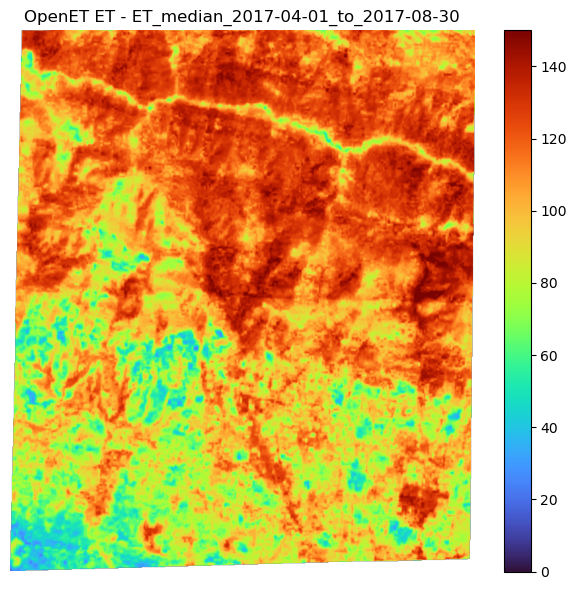

Saved aligned raster: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/ET_median_2017-04-01_to_2017-08-30_aligned.tif


PosixPath('/mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/ET_median_2017-04-01_to_2017-08-30_aligned.tif')

In [5]:
PRODUCT = 'ET'  # 'LAI', 'NDVI', or 'ET'

# Median/mean layer settings.
LAYER_MODE = 'median'  # 'median', 'mean', 'min', 'max', or 'closest'
LAYER_START_DATE = '2017-04-01'
LAYER_END_DATE = '2017-08-30'

# Closest-image settings, used only when LAYER_MODE = 'closest'.
TARGET_DATE = '2017-10-01'
SEARCH_DAYS = 30

product = PRODUCT.upper()
mode = LAYER_MODE.lower()

if mode == 'closest':
    layer, n_found, actual_date = closest_layer(product, TARGET_DATE, search_days=SEARCH_DAYS)
    label = f'{product}_closest_to_{TARGET_DATE}_actual_{actual_date}'
    print('Images searched:', n_found)
    print('Closest image date:', actual_date)
else:
    layer, n_found = composite_layer(product, LAYER_START_DATE, LAYER_END_DATE, reducer=mode)
    label = f'{product}_{mode}_{LAYER_START_DATE}_to_{LAYER_END_DATE}'
    print('Images used:', n_found)

layer_path = export_layer_to_local(product, layer, label=label)
layer_path

## 6. AOI-Aggregated Time Series

This reduces every available image in the selected window over the AOI and saves local CSV and PNG files.

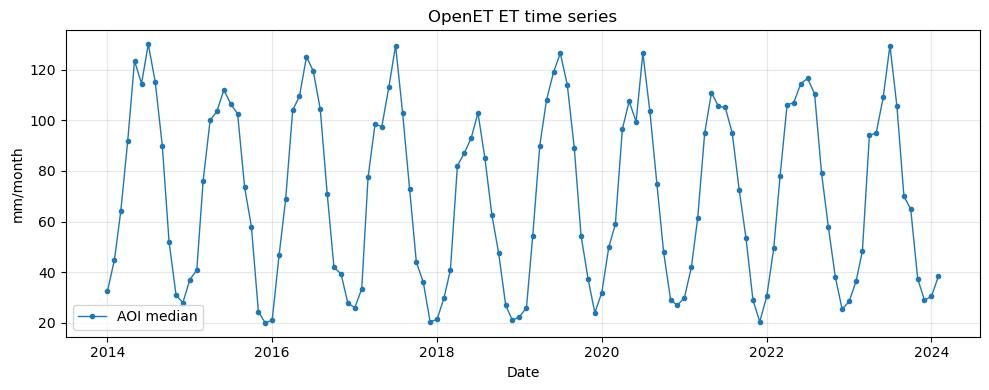

Images reduced: 122
Saved CSV: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/ET_timeseries_2014-01-01_to_2024-02-28.csv
Saved plot: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/ET_timeseries_2014-01-01_to_2024-02-28.png


,count,date,mean,median,product,stdDev
0,64830,2014-01-01,32.198892,32.494020,ET,12.885356
1,64830,2014-02-01,45.032942,45.000000,ET,15.408901
2,64830,2014-03-01,60.860781,64.000000,ET,19.744180
3,64830,2014-04-01,88.024156,92.000000,ET,36.005088
4,64830,2014-05-01,118.986828,123.476175,ET,37.386146


In [6]:
TS_PRODUCT = 'ET'  # 'LAI', 'NDVI', or 'ET'
TS_START_DATE = '2014-01-01'
TS_END_DATE = '2024-02-28'
TS_REDUCER_SCALE = None  # None uses native scale; set 30/500/etc. to override

def aoi_time_series(product, start_date, end_date, scale=None):
    product = product.upper()
    scale = scale or PRODUCTS[product]['native_scale']
    collection = product_collection(product, start_date, end_date)
    n = int(collection.size().getInfo())
    if n == 0:
        raise ValueError(f'No {product} images found for {start_date} to {end_date}')

    reducer = (
        ee.Reducer.mean()
        .combine(ee.Reducer.median(), sharedInputs=True)
        .combine(ee.Reducer.stdDev(), sharedInputs=True)
        .combine(ee.Reducer.count(), sharedInputs=True)
    )

    def image_to_feature(img):
        stats = img.reduceRegion(
            reducer=reducer,
            geometry=AOI_EE,
            scale=scale,
            maxPixels=1e13,
            bestEffort=True,
            tileScale=4,
        )
        date = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd')
        return ee.Feature(None, {
            'date': date,
            'product': product,
            'mean': stats.get('value_mean'),
            'median': stats.get('value_median'),
            'stdDev': stats.get('value_stdDev'),
            'count': stats.get('value_count'),
        })

    fc = ee.FeatureCollection(collection.map(image_to_feature))
    info = fc.getInfo()
    rows = [feature['properties'] for feature in info['features']]
    df = pd.DataFrame(rows)
    if not df.empty:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
    return df, n

ts_product = TS_PRODUCT.upper()
ts_df, ts_n = aoi_time_series(ts_product, TS_START_DATE, TS_END_DATE, TS_REDUCER_SCALE)
csv_path = OUT_DIR / f'{ts_product}_timeseries_{TS_START_DATE}_to_{TS_END_DATE}.csv'
png_path = OUT_DIR / f'{ts_product}_timeseries_{TS_START_DATE}_to_{TS_END_DATE}.png'
ts_df.to_csv(csv_path, index=False)

fig, ax = plt.subplots(figsize=(10, 4))
# ax.plot(ts_df['date'], ts_df['mean'], marker='o', linewidth=1.5, label='AOI mean')
ax.plot(ts_df['date'], ts_df['median'], marker='.', linewidth=1.0, label='AOI median')
ax.set_title(f"{PRODUCTS[ts_product]['label']} time series")
ax.set_ylabel(PRODUCTS[ts_product]['units'])
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig(png_path, dpi=200)
plt.show()

print('Images reduced:', ts_n)
print('Saved CSV:', csv_path)
print('Saved plot:', png_path)
ts_df.head()

## 7. Change Detection

This builds pre and post composites, subtracts `pre` from `post`, then exports all three aligned rasters.

Aligning to reference raster: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_pre_aligned.tif
Saved plot: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_pre.png


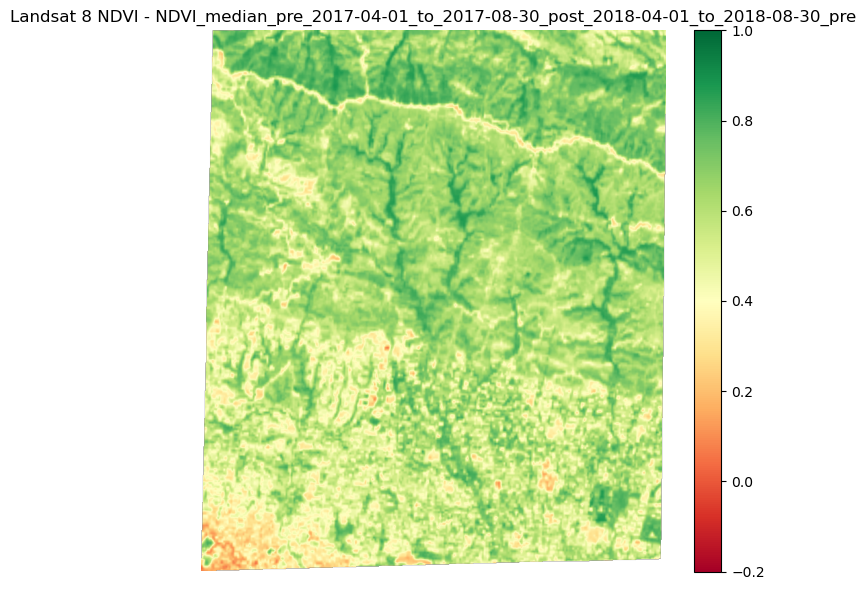

Saved aligned raster: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_pre_aligned.tif
Aligning to reference raster: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_post_aligned.tif
Saved plot: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_post.png


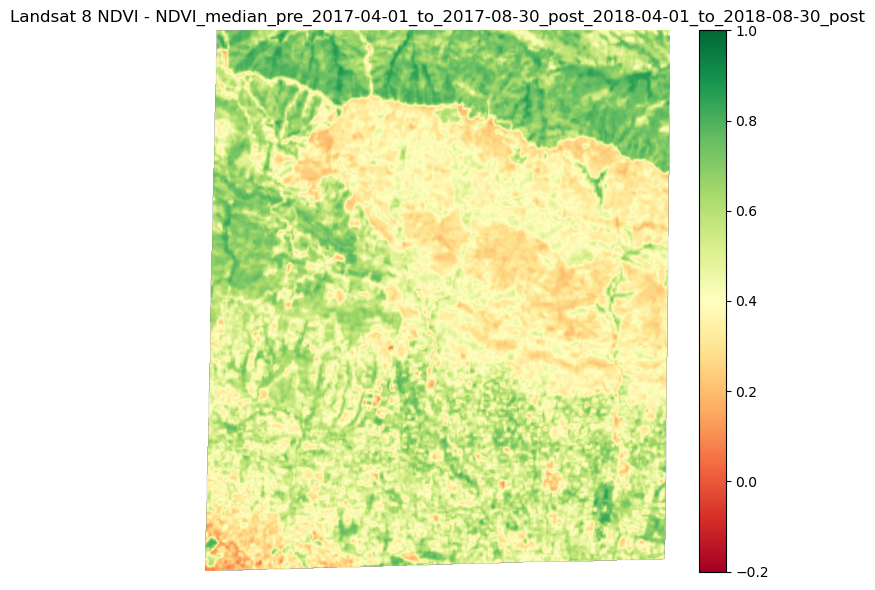

Saved aligned raster: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_post_aligned.tif
Aligning to reference raster: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_diff_post_minus_pre_aligned.tif
Saved plot: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_diff_post_minus_pre.png


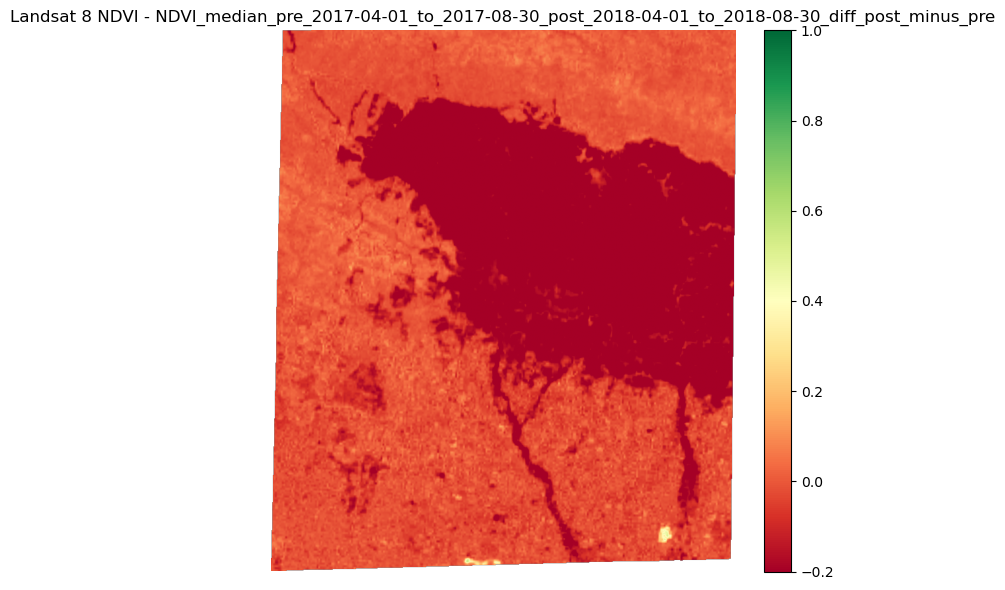

Saved aligned raster: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_diff_post_minus_pre_aligned.tif


/tmp/ipykernel_62504/1186620874.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


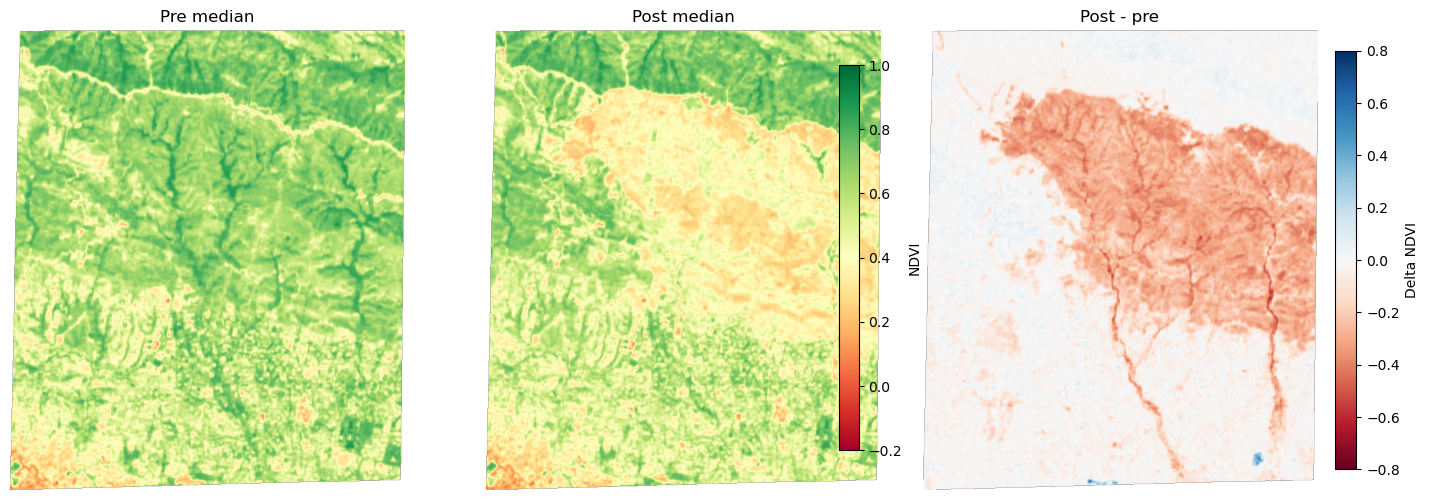

Pre images: 9
Post images: 9
Saved pre raster: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_pre_aligned.tif
Saved post raster: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_post_aligned.tif
Saved diff raster: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_diff_post_minus_pre_aligned.tif
Saved summary plot: /mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_change_summary.png


In [10]:
CHANGE_PRODUCT = 'NDVI'  # 'LAI', 'NDVI', or 'ET'
PRE_START_DATE = '2017-04-01'
PRE_END_DATE = '2017-08-30'
POST_START_DATE = '2018-04-01'
POST_END_DATE = '2018-08-30'
CHANGE_REDUCER = 'median'

change_product = CHANGE_PRODUCT.upper()
pre_img, pre_n = composite_layer(change_product, PRE_START_DATE, PRE_END_DATE, reducer=CHANGE_REDUCER)
post_img, post_n = composite_layer(change_product, POST_START_DATE, POST_END_DATE, reducer=CHANGE_REDUCER)
diff_img = post_img.subtract(pre_img).rename(f'{change_product}_diff_post_minus_pre').clip(AOI_EE)

base = f'{change_product}_{CHANGE_REDUCER}_pre_{PRE_START_DATE}_to_{PRE_END_DATE}_post_{POST_START_DATE}_to_{POST_END_DATE}'
pre_path = export_layer_to_local(change_product, pre_img, label=f'{base}_pre')
post_path = export_layer_to_local(change_product, post_img, label=f'{base}_post')
diff_path = export_layer_to_local(change_product, diff_img, label=f'{base}_diff_post_minus_pre')

cfg = PRODUCTS[change_product]
pre_arr = read_raster_for_plot(pre_path)
post_arr = read_raster_for_plot(post_path)
diff_arr = read_raster_for_plot(diff_path)

summary_png = OUT_DIR / f'{base}_change_summary.png'
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im0 = axes[0].imshow(pre_arr, cmap=cfg['cmap'], vmin=cfg['vmin'], vmax=cfg['vmax'])
axes[0].set_title(f'Pre {CHANGE_REDUCER}')
im1 = axes[1].imshow(post_arr, cmap=cfg['cmap'], vmin=cfg['vmin'], vmax=cfg['vmax'])
axes[1].set_title(f'Post {CHANGE_REDUCER}')
im2 = axes[2].imshow(diff_arr, cmap='RdBu', vmin=cfg['diff_vmin'], vmax=cfg['diff_vmax'])
axes[2].set_title('Post - pre')
for ax in axes:
    ax.axis('off')
fig.colorbar(im0, ax=axes[:2], fraction=0.046, pad=0.04, label=cfg['units'])
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label=f"Delta {cfg['units']}")
plt.tight_layout()
fig.savefig(summary_png, dpi=200)
plt.show()

print('Pre images:', pre_n)
print('Post images:', post_n)
print('Saved pre raster:', pre_path)
print('Saved post raster:', post_path)
print('Saved diff raster:', diff_path)
print('Saved summary plot:', summary_png)

## Notes

- For a large AOI, direct local download can fail because Earth Engine limits interactive downloads. If that happens, reduce the AOI, use a coarser scale, or switch to `ee.batch.Export.image.toDrive`.
- LAI is natively coarse MODIS data. Aligning it to a 10 m or 30 m DEM grid is useful for stacking rasters, but it does not create finer native information.
- ET is monthly, so a `closest` ET layer represents the closest monthly image in the search window.
- NDVI uses Landsat 8 only to match the pasted script. Add Landsat 9 if you want a denser post-2021 record.

In [17]:
from pathlib import Path
import pandas as pd
import requests

# Assumes you already ran setup cells from gee_lai_ndvi_et_workflow.ipynb:
# AOI_GEOJSON, product_collection, PRODUCTS

OUT_JPG = Path("/mnt/c/Users/amehedi/Downloads/gee_monthly_jpg")
OUT_JPG.mkdir(parents=True, exist_ok=True)

START_DATE = "2018-09-01"
END_DATE = "2019-12-30" 

PRODUCT_LIST = ["ET", "NDVI"]

def save_monthly_median_jpg(product, start_date, end_date):
    product = product.upper()
    cfg = PRODUCTS[product]

    months = pd.date_range(start=start_date, end=end_date, freq="MS")

    for month_start in months:
        month_end = month_start + pd.DateOffset(months=1)

        start = month_start.strftime("%Y-%m-%d")
        end = month_end.strftime("%Y-%m-%d")
        label = month_start.strftime("%Y_%m")

        collection = product_collection(product, start, end)

        if int(collection.size().getInfo()) == 0:
            print("No images:", product, label)
            continue

        img = collection.median().clip(AOI_EE)

        url = img.getThumbURL({
            "region": AOI_GEOJSON,
            "dimensions": 1200,
            "format": "jpg",
            "min": cfg["vmin"],
            "max": cfg["vmax"],
            "palette": ["blue", "cyan", "yellow", "orange", "red"] if product == "ET"
                       else ["brown", "yellow", "green"],
        })

        out_path = OUT_JPG / f"{product}_median_{label}.jpg"
        r = requests.get(url, timeout=300)
        r.raise_for_status()
        out_path.write_bytes(r.content)

        print("saved:", out_path)

for product in PRODUCT_LIST:
    save_monthly_median_jpg(product, START_DATE, END_DATE)

saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_median_2018_09.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_median_2018_10.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_median_2018_11.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_median_2018_12.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_median_2019_01.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_median_2019_02.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_median_2019_03.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_median_2019_04.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_median_2019_05.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_median_2019_06.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_median_2019_07.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_median_2019_08.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_median_2019_09.jpg
saved: /mnt/

In [16]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling

burn_path = Path("/mnt/c/Users/amehedi/Downloads/thomas/burn_severity_thomas.tif")
aoi_path = Path("/mnt/c/Users/amehedi/Downloads/thomas/montecito_aoi.shp")
ref_path = Path("/mnt/c/Users/amehedi/Downloads/thomas/topographic__elevation.tif")

out_path = Path("/mnt/c/Users/amehedi/Downloads/thomas/burn_severity_montecito_aoi_aligned.tif")

src_nodata = 255      # valid for uint8
dst_nodata = -9999.0  # final float raster nodata

aoi = gpd.read_file(aoi_path)

with rasterio.open(burn_path) as src:
    aoi_src = aoi.to_crs(src.crs)

    clipped, clipped_transform = mask(
        src,
        aoi_src.geometry,
        crop=True,
        nodata=src_nodata,
        filled=True,
    )

    clipped = clipped[0].astype("float32")
    clipped[clipped == src_nodata] = dst_nodata

    src_crs = src.crs

with rasterio.open(ref_path) as ref:
    ref_arr = ref.read(1)
    ref_invalid = ~np.isfinite(ref_arr)
    if ref.nodata is not None:
        ref_invalid |= np.isclose(ref_arr, ref.nodata)

    aligned = np.full((ref.height, ref.width), dst_nodata, dtype="float32")

    reproject(
        source=clipped,
        destination=aligned,
        src_transform=clipped_transform,
        src_crs=src_crs,
        src_nodata=dst_nodata,
        dst_transform=ref.transform,
        dst_crs=ref.crs,
        dst_nodata=dst_nodata,
        resampling=Resampling.nearest,
    )

    aligned[ref_invalid] = dst_nodata

    profile = ref.profile.copy()
    profile.update(
        driver="GTiff",
        dtype="float32",
        count=1,
        nodata=dst_nodata,
        compress="deflate",
    )

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(aligned, 1)

print("saved:", out_path)

saved: /mnt/c/Users/amehedi/Downloads/thomas/burn_severity_montecito_aoi_aligned.tif


In [19]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

IMG_DIR = Path("/mnt/c/Users/amehedi/Downloads/gee_monthly_jpg")

image_paths = sorted(IMG_DIR.glob("ET_median_*.jpg"))

ROWS = 2
COLS = 4
GROUP_SIZE = ROWS * COLS

for group_i in range(math.ceil(len(image_paths) / GROUP_SIZE)):
    group = image_paths[group_i * GROUP_SIZE : (group_i + 1) * GROUP_SIZE]

    fig, axes = plt.subplots(ROWS, COLS, figsize=(14, 7))
    axes = axes.ravel()

    for ax, path in zip(axes, group):
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.set_title(path.stem.replace("ET_median_", ""), fontsize=10)
        ax.axis("off")

    for ax in axes[len(group):]:
        ax.axis("off")

    plt.tight_layout()

    out_path = IMG_DIR / f"ET_combined_2x4_group_{group_i + 1:02d}.jpg"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

    print("saved:", out_path)

saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_combined_2x4_group_01.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_combined_2x4_group_02.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_combined_2x4_group_03.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_combined_2x4_group_04.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_combined_2x4_group_05.jpg
saved: /mnt/c/Users/amehedi/Downloads/gee_monthly_jpg/ET_combined_2x4_group_06.jpg


ModuleNotFoundError: No module named 'pci_source_zones'